In [21]:
import cv2
import matplotlib.pyplot as plt
import numpy as np


def show_cv_image(img):
    # Check if the image is a black-and-whie image (only 2 dimensions)
    # In this case, it is only a binary 0 for black and 1 for white
    if len(img.shape) == 2:
        pass
    # Check if the image has 3 color dimensions (BGR).
    # If it does, we need to convert from OpenCV BGR to RGB before showing.
    elif img.shape[2] == 3:
        img = cv2.cvtColor(img,  cv2.COLOR_BGR2RGB)
    # Check if the image has 4 color dimensions (BGRA).
    # If it does, we need to convert from OpenCV BGRA to RGBA before showing.
    elif img.shape[2] == 4:
        img = cv2.cvtColor(img,  cv2.COLOR_BGRA2RGBA)
    else:
        raise ValueError(f"Unknown image shape: {img.shape}")
    plt.imshow(img)
    plt.show()

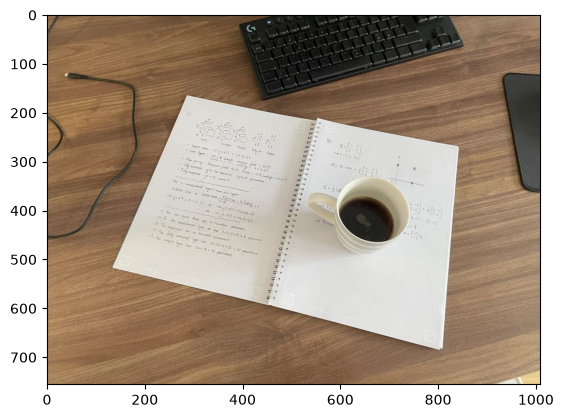

In [73]:
img_file = "../tests/images/IMG_1846.jpg"
img = cv2.imread(img_file)
show_cv_image(img)

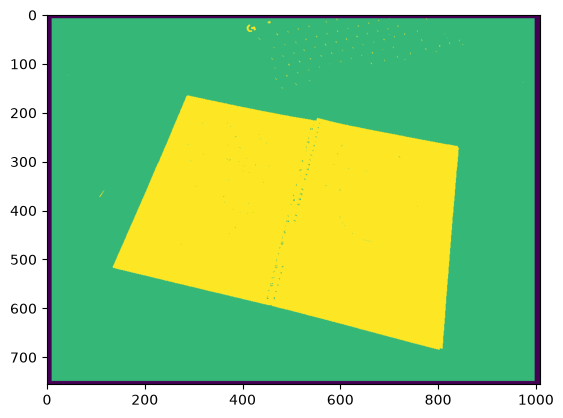

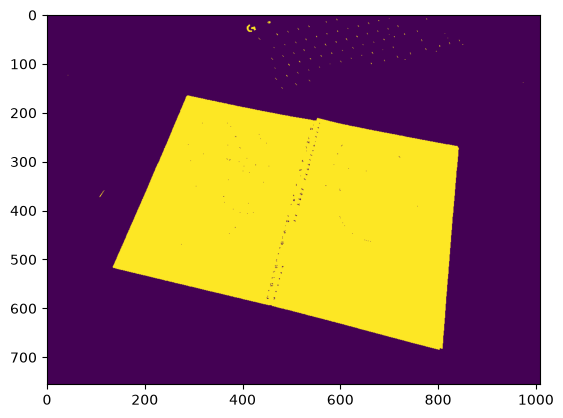

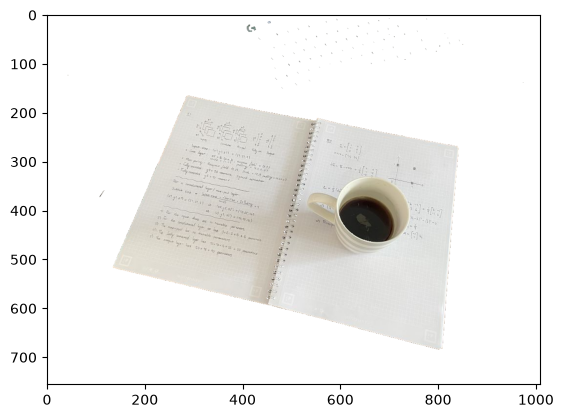

In [74]:
height, width = img.shape[:2]
margin = 0.01  # 5% margin
x = int(width * margin)
y = int(height * margin)
rect = (x, y, width - 2*x, height - 2*y)

# Create mask and models
mask = np.zeros(img.shape[:2], np.uint8)
bgdModel = np.zeros((1, 65), np.float64)
fgdModel = np.zeros((1, 65), np.float64)

# Apply GrabCut
cv2.grabCut(img, mask, rect, bgdModel, fgdModel, 5, cv2.GC_INIT_WITH_RECT)

# Create binary mask
mask2 = np.where((mask == 2) | (mask == 0), 0, 1).astype("uint8")

# Convert to RGBA and apply mask to alpha channel
output_rgba = cv2.cvtColor(img, cv2.COLOR_BGR2BGRA)
output_rgba[:, :, 3] = mask2 * 255  # 0 for background, 255 for foreground

show_cv_image(mask)
show_cv_image(mask2)
show_cv_image(output_rgba)

(14, 2)


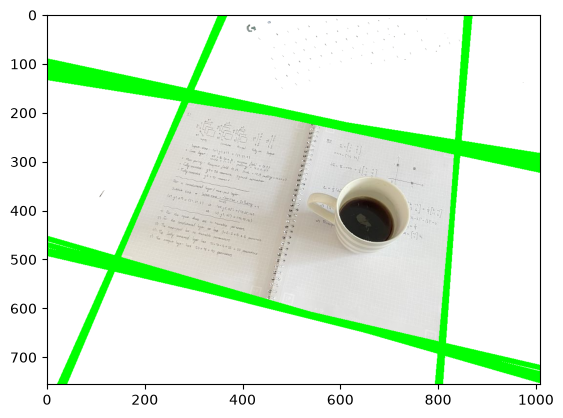

In [75]:
from camscan.scanner import draw_hough_lines

# We can remove unnecessary details from the image by applying a Gaussian
# blur, which will suppress high frequency noise (like the actual text on
# the pages of a document) while leaving larger details (like the actual
# contour of the document).
img_scale_gray_blur = cv2.GaussianBlur(
    src=mask2,
    ksize=(51, 51),
    sigmaX=0,
)

# We can then apply the Canny edge detection algorithm to the image
img_edge = cv2.Canny(
    image=img_scale_gray_blur,
    threshold1=0,
    threshold2=1,
)

lines = cv2.HoughLines(
    image=img_edge,
    rho=2,
    theta=np.pi / 180,
    threshold=100,
)

img_hough_preview = output_rgba.copy()

# HoughLines produces an array with shape (num_lines, 1, 2) which we are
# reshaping to (num_lines, 2)
lines = lines.reshape((lines.shape[0], lines.shape[2]))
print(lines.shape)
img_hough_preview = draw_hough_lines(image=img_hough_preview, lines=lines, color=(0, 255, 0, 255), thickness=10)

show_cv_image(img_hough_preview)
